# Movie Genre Classification
**CodSoft Machine Learning Internship**

---
Classify movies into genres based on their plot descriptions using **Logistic Regression**.


## 📦 Step 1: Imports

In [ ]:
import os, re, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)


##  Loading & Cleaning Data

In [ ]:

project_root = Path.cwd().resolve()
train_candidates = [
    project_root / 'Genre Classification Dataset' / 'train_data.txt',
    project_root.parent / 'Genre Classification Dataset' / 'train_data.txt',
    project_root / '..' / 'Genre Classification Dataset' / 'train_data.txt',
]
TRAIN_FILE = next((p for p in train_candidates if p.exists()), train_candidates[0])


def load_genre_dataset(filepath):
    rows=[]
    with open(filepath,'r',encoding='utf-8',errors='replace') as f:
        for line in f:
            parts= [p.strip() for p in line.strip().split(':::')]
            if len(parts)==4:
                rows.append({
                    'title': parts[1],
                    'genre': parts[2].lower(),
                    'description': parts[3]
                })
    return pd.DataFrame(rows)

df = load_genre_dataset(TRAIN_FILE)

# Simple text cleaning
def clean_text(text):
    text= str(text).lower()
    text= re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Combine title and description
df['text'] =df['title'].apply(clean_text) + ' ' + df['description'].apply(clean_text)

#top 10 genres to keep it simple and improve accuracy
top_10_genres= df['genre'].value_counts().head(10).index
df = df[df['genre'].isin(top_10_genres)].copy()

print(f'✅ Loaded & Cleaned {len(df):,} rows')
df.head(3)

✅ Loaded & Cleaned 47,039 rows


,title,genre,description,text
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...,oscar et la dame rose listening in to a conver...
1,Cupid (1997),thriller,A brother and sister with a past incestuous re...,cupid a brother and sister with a past incestu...
3,The Secret Sin (1915),drama,To help their unemployed father make ends meet...,the secret sin to help their unemployed father...


## Simple EDA

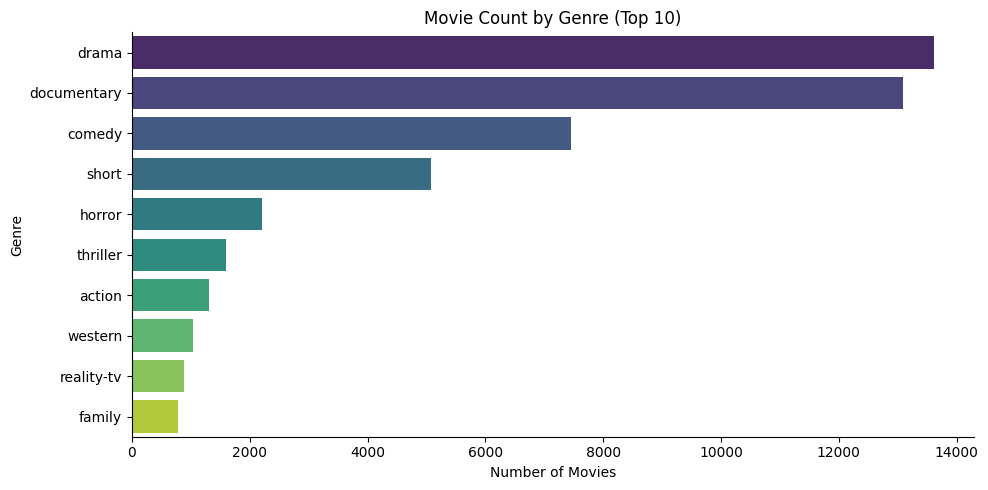

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='genre', order=df['genre'].value_counts().index, palette='viridis')
plt.title('Movie Count by Genre (Top 10)')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

## Logistic Regression

In [ ]:
X = df['text']
y = df['genre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating Pipeline: 
model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, stop_words='english', ngram_range=(1,2))),
    ('lr', LogisticRegression(C=2.0, max_iter=500, random_state=42))
])

print("Training Logistic Regression model...")
model.fit(X_train, y_train)
print("✅ Training complete!")

Training Logistic Regression model...
✅ Training complete!


## Confusion Matrix

⭐ Accuracy: 66.22%

              precision    recall  f1-score   support

      action       0.64      0.33      0.44       264
      comedy       0.60      0.62      0.61      1475
 documentary       0.76      0.85      0.80      2642
       drama       0.62      0.78      0.69      2722
      family       0.62      0.14      0.22       155
      horror       0.74      0.60      0.67       450
  reality-tv       0.71      0.19      0.30       168
       short       0.52      0.35      0.42       978
    thriller       0.45      0.14      0.22       341
     western       0.96      0.73      0.83       213

    accuracy                           0.66      9408
   macro avg       0.66      0.47      0.52      9408
weighted avg       0.65      0.66      0.64      9408



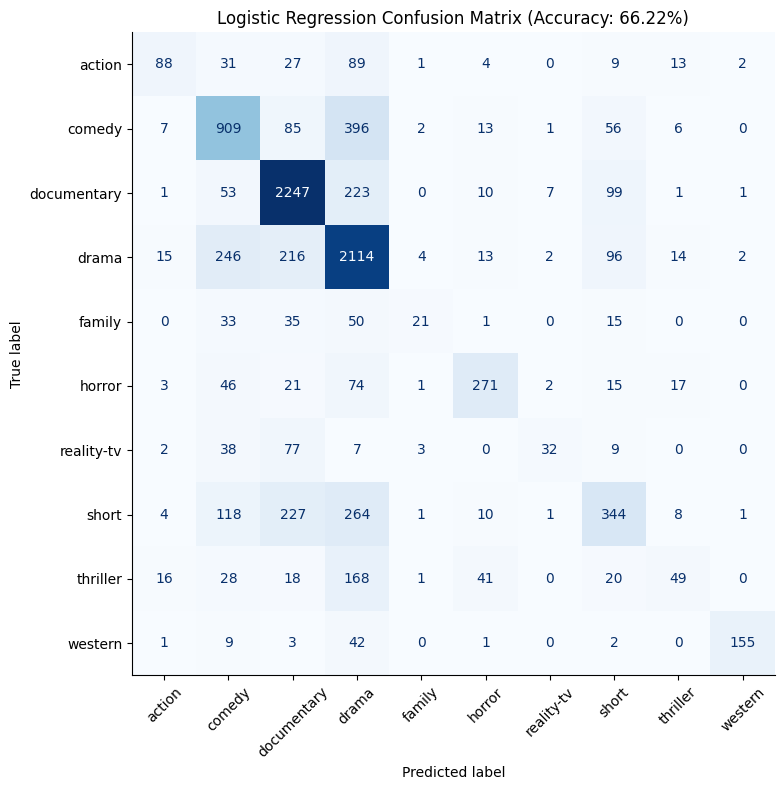

In [25]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"⭐ Accuracy: {acc*100:.2f}%\n")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    cmap='Blues', 
    xticks_rotation=45, 
    ax=ax,
    colorbar=False
)
ax.set_title(f'Logistic Regression Confusion Matrix (Accuracy: {acc*100:.2f}%)')
plt.tight_layout()
plt.show()

## Predict on New Text

In [26]:
def predict_genre(description):
    clean_desc = clean_text(description)
    pred = model.predict([clean_desc])[0]
    print(f'\n📝 Text: {description[:100]}...')
    print(f'🎯 Predicted Genre: {pred.upper()}')

# testing it with our inputs or queries....
predict_genre("A detective investigates a series of brutal murders in a dark rainy city, chasing a serial killer.")
predict_genre("Two star-crossed lovers from rival families fight for their relationship amidst a bitter feud.")
predict_genre("A hilarious journey of three friends taking a road trip across the country before college begins.")


📝 Text: A detective investigates a series of brutal murders in a dark rainy city, chasing a serial killer....
🎯 Predicted Genre: THRILLER

📝 Text: Two star-crossed lovers from rival families fight for their relationship amidst a bitter feud....
🎯 Predicted Genre: DRAMA

📝 Text: A hilarious journey of three friends taking a road trip across the country before college begins....
🎯 Predicted Genre: COMEDY
